In [1]:
# Import basic libraries for data handling and visualization

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
# Upload dataset in Colab first
# Load dataset
df = pd.read_csv("/content/spotify_tracks.csv")

# Display first 5 rows
df.head()

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,-4.702460,0.050635,0.239506,0.181395,0.133053,0.431384,141.048735,6,0,4
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,-7.110031,0.000000,0.044463,0.097818,0.435949,0.559135,131.833287,0,1,5
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,-7.305120,0.144091,0.118380,0.000000,0.262254,0.516873,127.132954,2,1,5
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,-9.527256,0.006668,0.272844,0.000000,0.045332,0.667911,93.041715,0,1,6
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,-9.017653,0.057632,0.219752,0.098044,0.132083,0.772151,93.404975,7,1,4


In [4]:
# Check dataset shape
print("Dataset shape:", df.shape)

# Column names
print("\nColumns in dataset:\n", df.columns)

# Basic information
df.info()

Dataset shape: (50000, 21)

Columns in dataset:
 Index(['track_id', 'track_name', 'artist_name', 'album_name', 'release_year',
       'genre', 'popularity', 'duration_ms', 'explicit', 'danceability',
       'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'key', 'mode', 'time_signature'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          50000 non-null  object 
 1   track_name        50000 non-null  object 
 2   artist_name       50000 non-null  object 
 3   album_name        50000 non-null  object 
 4   release_year      50000 non-null  int64  
 5   genre             50000 non-null  object 
 6   popularity        50000 non-null  int64  
 7   duration_ms       50000 non-null  int64  
 8   explicit          50000 non-null  bool   

In [5]:
# Check null values
df.isnull().sum()

,0
track_id,0
track_name,0
artist_name,0
album_name,0
release_year,0
genre,0
popularity,0
duration_ms,0
explicit,0
danceability,0


In [7]:
df.dtypes

,0
track_id,object
track_name,object
artist_name,object
album_name,object
release_year,int64
genre,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64


In [8]:
# Convert explicit (True/False) into 1 and 0

df['explicit'] = df['explicit'].astype(int)

df['explicit'].head()

,explicit
0,1
1,1
2,0
3,0
4,0


In [11]:
# Find all unique genres

df['genre'].unique()

array(['metal', 'rock', 'k-pop', 'latin', 'electronic', 'soul',
       'classical', 'jazz', 'country', 'folk', 'pop', 'punk', 'r&b',
       'gospel', 'hip-hop', 'ambient', 'blues', 'drum-and-bass', 'indie',
       'reggae'], dtype=object)

In [15]:
# Convert genres to numerical labels

df['genre_encoded'] = pd.factorize(df['genre'])[0] + 1

df[['genre','genre_encoded']].head(20)

,genre,genre_encoded
0,metal,1
1,rock,2
2,k-pop,3
3,latin,4
4,latin,4
5,electronic,5
6,electronic,5
7,soul,6
8,classical,7
9,jazz,8


In [10]:
# Frequency encoding for artist_name

artist_freq = df['artist_name'].value_counts()

df['artist_encoded'] = df['artist_name'].map(artist_freq)

df[['artist_name','artist_encoded']].head()

,artist_name,artist_encoded
0,Alex Rodriguez,72
1,Desert Wind,1021
2,The Midnight,985
3,Phantom Keys,1098
4,Desert Wind,1021


In [16]:
df.columns

Index(['track_id', 'track_name', 'artist_name', 'album_name', 'release_year',
       'genre', 'popularity', 'duration_ms', 'explicit', 'danceability',
       'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'key', 'mode', 'time_signature',
       'artist_encoded', 'genre_encoded'],
      dtype='object')

In [17]:
df.head(5)

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature,artist_encoded,genre_encoded
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,1,0.427723,...,0.239506,0.181395,0.133053,0.431384,141.048735,6,0,4,72,1
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,1,0.448634,...,0.044463,0.097818,0.435949,0.559135,131.833287,0,1,5,1021,2
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,0,0.707923,...,0.118380,0.000000,0.262254,0.516873,127.132954,2,1,5,985,3
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,0,0.846237,...,0.272844,0.000000,0.045332,0.667911,93.041715,0,1,6,1098,4
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,0,0.943720,...,0.219752,0.098044,0.132083,0.772151,93.404975,7,1,4,1021,4


In [18]:
features = df[['release_year','genre_encoded','popularity','duration_ms', 'explicit','danceability','energy','loudness','speechiness',
               'acousticness','instrumentalness','liveness',
               'valence','tempo',  'key', 'mode', 'time_signature']]

In [19]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features = pd.DataFrame(scaled_features, columns=features.columns)

scaled_features.head()

,release_year,genre_encoded,popularity,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
0,1.318615,-1.558024,-0.535916,-0.466450,2.678920,-0.959940,1.601894,0.635520,-0.395993,-0.141275,0.111184,-0.496634,-0.815573,1.045751,0.145268,-1.277062,-0.083279
1,0.509311,-1.374010,-0.703397,-0.516293,2.678920,-0.859166,0.338260,0.076348,-1.175121,-0.897522,-0.243799,2.632890,-0.121244,0.657010,-1.521988,0.783048,1.862496
2,0.994894,-1.189996,-0.033472,-1.964354,-0.373285,0.390351,0.404405,0.031037,1.042052,-0.610919,-0.659265,0.838280,-0.350936,0.458733,-0.966236,0.783048,1.862496
3,1.318615,-1.005982,0.580627,0.135291,-0.373285,1.056885,0.924788,-0.485066,-1.072515,-0.012011,-0.659265,-1.402960,0.469957,-0.979358,-1.521988,0.783048,3.808271
4,-0.947436,-1.005982,0.413145,-1.198870,-0.373285,1.526659,0.952693,-0.366708,-0.288328,-0.217868,-0.242839,-0.506655,1.036503,-0.964034,0.423144,0.783048,-0.083279


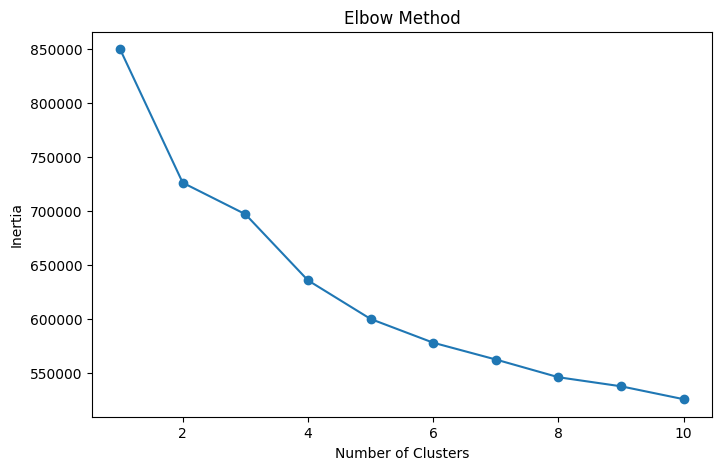

In [24]:
# Create an empty list to store inertia values
# Inertia measures how compact the clusters are
# Lower inertia means better clustering
inertia = []

# We will test different numbers of clusters (K values)
# range(1,11) means we will test K = 1,2,3,...,10
for k in range(1,11):

    # Create a K-Means model with k clusters
    # n_clusters = number of clusters we want
    # random_state ensures we get the same result every time we run the code
    kmeans = KMeans(n_clusters=k, random_state=42)

    # Train (fit) the K-Means model on the scaled dataset
    # The algorithm will group the data into k clusters
    kmeans.fit(scaled_features)

    # After clustering, K-Means calculates the inertia value
    # inertia_ = sum of squared distances of data points from their cluster centers
    # We store this inertia value in the list
    inertia.append(kmeans.inertia_)

# Create a new figure for plotting the graph
# figsize controls the width and height of the plot
plt.figure(figsize=(8,5))

# Plot number of clusters (1–10) on X-axis and inertia values on Y-axis
# marker='o' adds circular markers at each point to make the plot clearer
plt.plot(range(1,11), inertia, marker='o')

# Label for the X-axis
# This shows the number of clusters used in K-Means
plt.xlabel("Number of Clusters")

# Label for the Y-axis
# This shows the inertia (cluster compactness)
plt.ylabel("Inertia")

# Title of the graph
# This method helps us choose the optimal number of clusters
plt.title("Elbow Method")

# Display the plot
plt.show()

In [21]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(scaled_features)

df.head()

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,instrumentalness,liveness,valence,tempo,key,mode,time_signature,artist_encoded,genre_encoded,Cluster
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,1,0.427723,...,0.181395,0.133053,0.431384,141.048735,6,0,4,72,1,2
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,1,0.448634,...,0.097818,0.435949,0.559135,131.833287,0,1,5,1021,2,2
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,0,0.707923,...,0.000000,0.262254,0.516873,127.132954,2,1,5,985,3,2
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,0,0.846237,...,0.000000,0.045332,0.667911,93.041715,0,1,6,1098,4,0
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,0,0.943720,...,0.098044,0.132083,0.772151,93.404975,7,1,4,1021,4,1


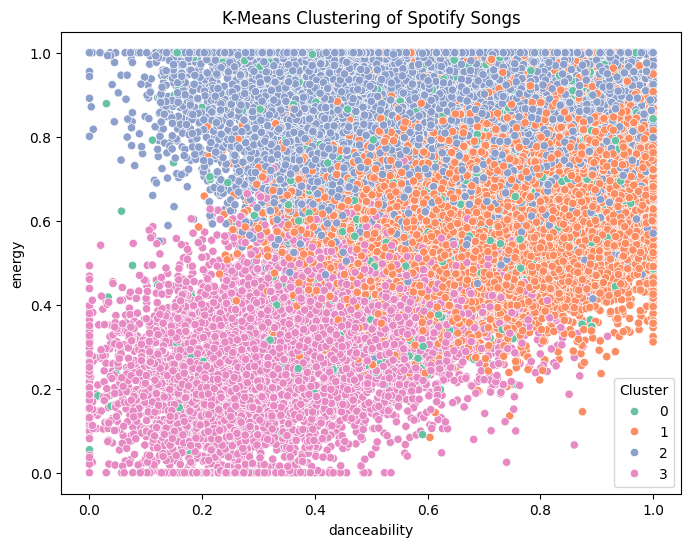

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['danceability'],
    y=df['energy'],
    hue=df['Cluster'],
    palette='Set2'
)

plt.title("K-Means Clustering of Spotify Songs")

plt.show()

In [23]:
df.groupby('Cluster')[features.columns].mean()

,release_year,genre_encoded,popularity,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
Cluster,,,,,,,,,,,,,,,,,
0,2016.078682,9.242771,24.617350,208902.498319,0.114997,0.651614,0.686237,-6.904267,0.079234,0.249237,0.123332,0.176891,0.591230,117.418800,5.481506,0.628110,6.344317
1,2015.862145,12.820166,23.475790,209850.670873,0.153543,0.722667,0.642194,-7.028257,0.104429,0.246820,0.046570,0.180649,0.640278,104.261139,5.485474,0.617852,3.968100
2,2015.824355,5.110291,23.653037,210160.035839,0.102025,0.607076,0.825006,-5.212588,0.054172,0.119889,0.114148,0.181864,0.542436,135.138379,5.467240,0.624799,3.969209
3,2015.851963,9.771488,23.644842,210130.811660,0.078388,0.383795,0.312675,-13.997958,0.044480,0.734679,0.581348,0.181595,0.496125,107.356072,5.475284,0.612886,3.991783
